# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Курс data analyst/Python/Візуалізація/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

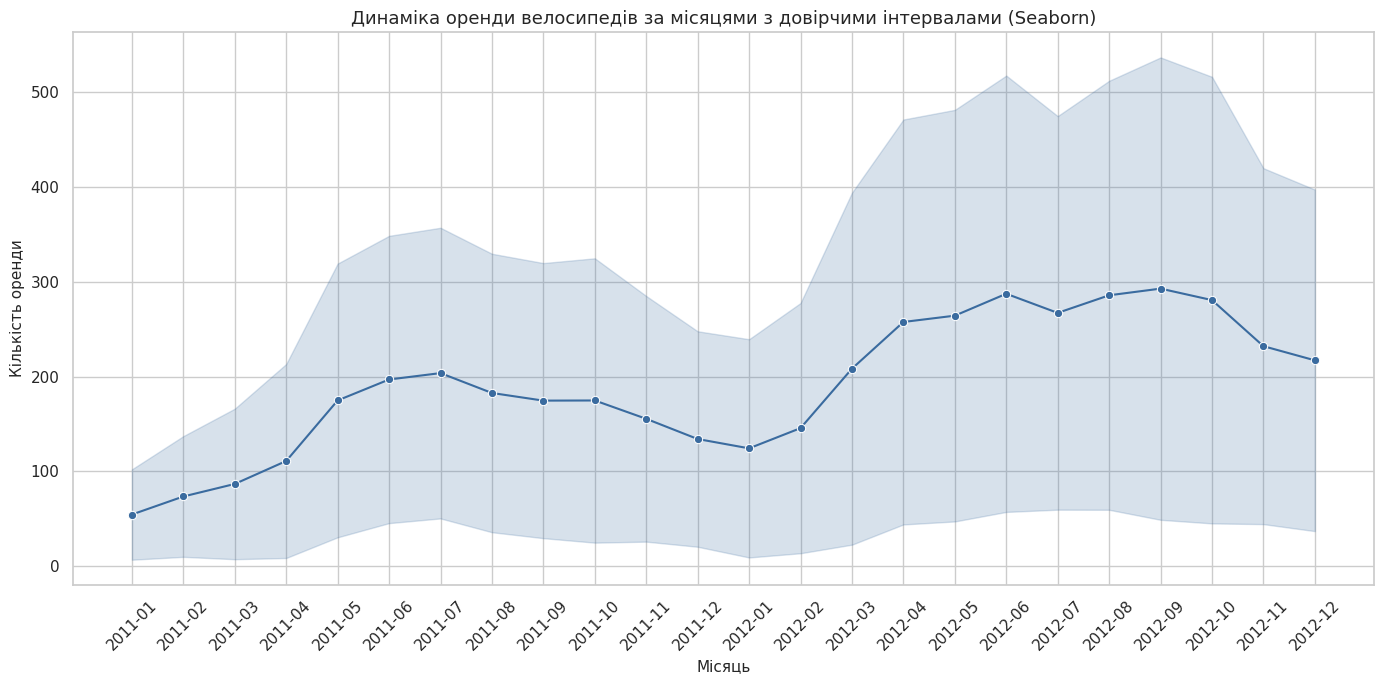

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    marker='o',
    errorbar='sd',
    color='#3a6b9f',
)
plt.title(
    'Динаміка оренди велосипедів за місяцями з довірчими інтервалами (Seaborn)',
    fontsize=13,
)
plt.xlabel('Місяць', fontsize=11)
plt.ylabel('Кількість оренди', fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()

Найбільша невизначеність в 2012-09.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

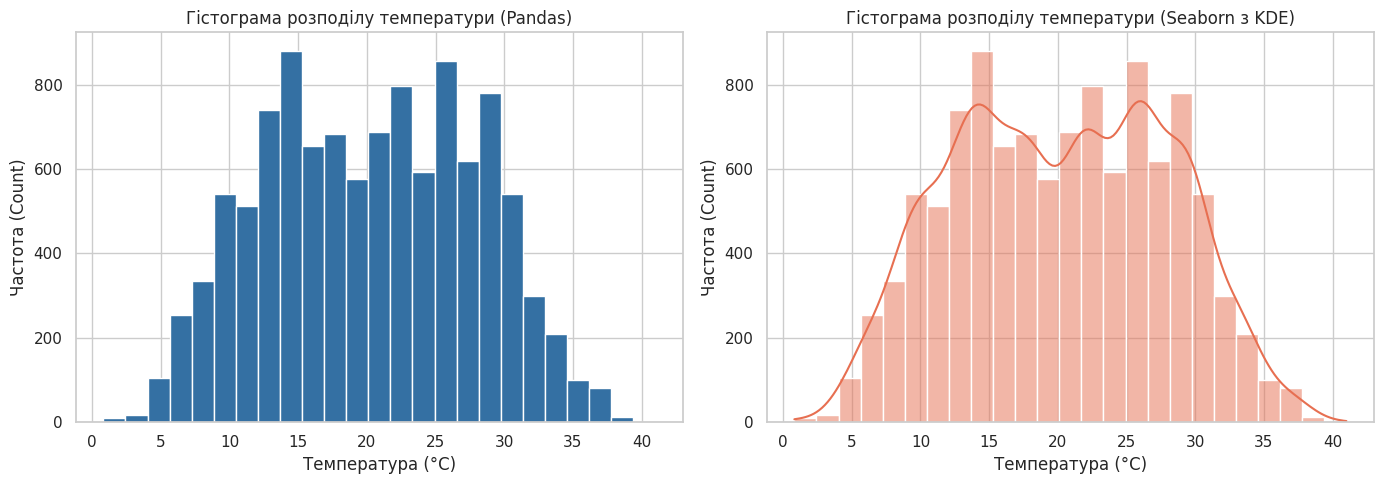

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['temp'].plot.hist(
    bins=25,
    ax=ax[0],
    color='#3470a3',
    edgecolor='white',
    grid=True,
    title='Гістограма розподілу температури (Pandas)'
)
ax[0].set_xlabel('Температура (°C)')
ax[0].set_ylabel('Частота (Count)')

sns.histplot(
    data=df,
    x='temp',
    bins=25,
    kde=True,
    ax=ax[1],
    color='#e76f51',
    edgecolor='white'
)
ax[1].set_title('Гістограма розподілу температури (Seaborn з KDE)')
ax[1].set_xlabel('Температура (°C)')
ax[1].set_ylabel('Частота (Count)')

plt.tight_layout()

Seaborn за замовчуванням має виразнішу палітру, охайніші межі стовпців і м'якші кольори. У Pandas гістограма виглядає більш базовою.
Лінія оцінки щільності ядра — KDE.
Це плавна неперервна крива, яка згладжує нерівності окремих стовпчиків і показує загальну форму (профіль) розподілу ймовірностей.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

/tmp/ipykernel_1628/3868317635.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


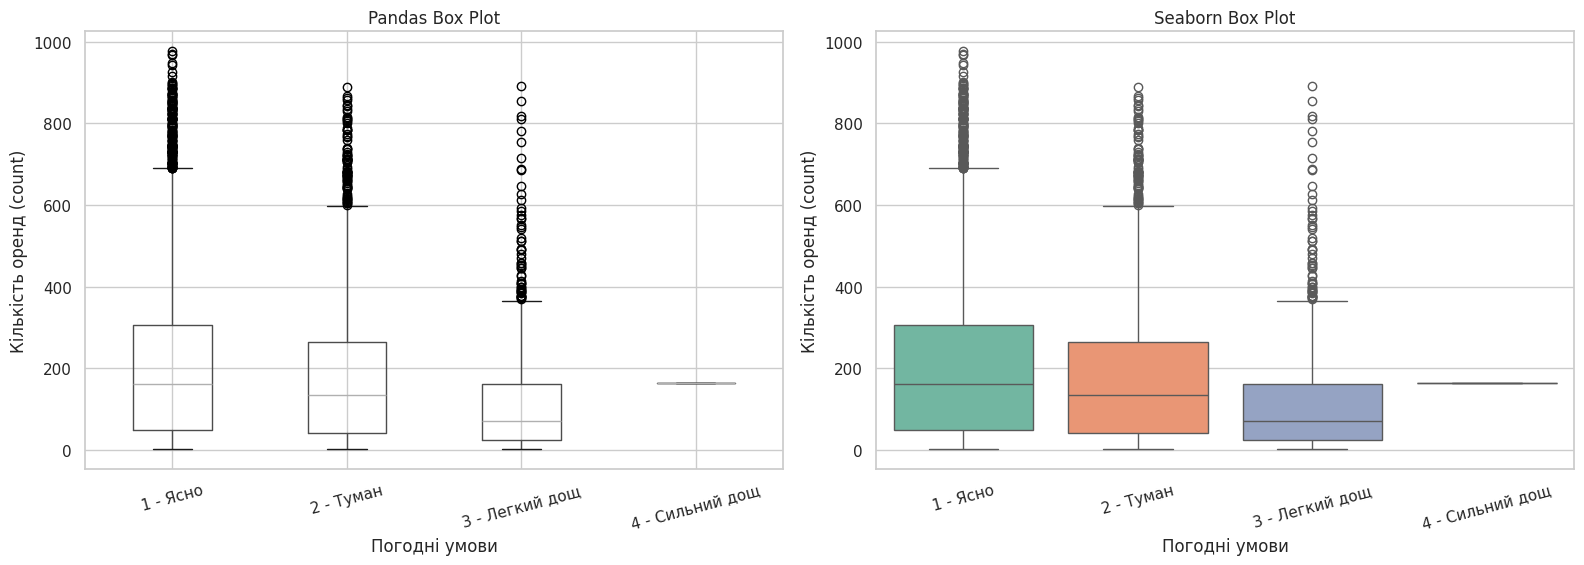

In [ ]:
weather_labels = {
    1: '1 - Ясно',
    2: '2 - Туман',
    3: '3 - Легкий дощ',
    4: '4 - Сильний дощ'
}
df['weather_desc'] = df['weather'].map(weather_labels)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
df.boxplot(
    column='count',
    by='weather_desc',
    ax=ax[0],
    grid=True
)
ax[0].set_title('Pandas Box Plot')
ax[0].set_xlabel('Погодні умови')
ax[0].set_ylabel('Кількість оренд (count)')
plt.suptitle('')

sns.boxplot(
    data=df,
    x='weather_desc',
    y='count',
    ax=ax[1],
    palette='Set2'
)
ax[1].set_title('Seaborn Box Plot')
ax[1].set_xlabel('Погодні умови')
ax[1].set_ylabel('Кількість оренд (count)')
ax[0].tick_params(axis='x', rotation=15)
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout();

Seaborn за замовчуванням автоматично розфарбовує кожну категорію погоди у свій приємний колір із палітри, тоді як Pandas будує монохромні білі коробки з тонкими чорними лініями. Seaborn використовує дрібніші, охайніші маркери з напівпрозорістю.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [ ]:
correlation = df[['season','holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

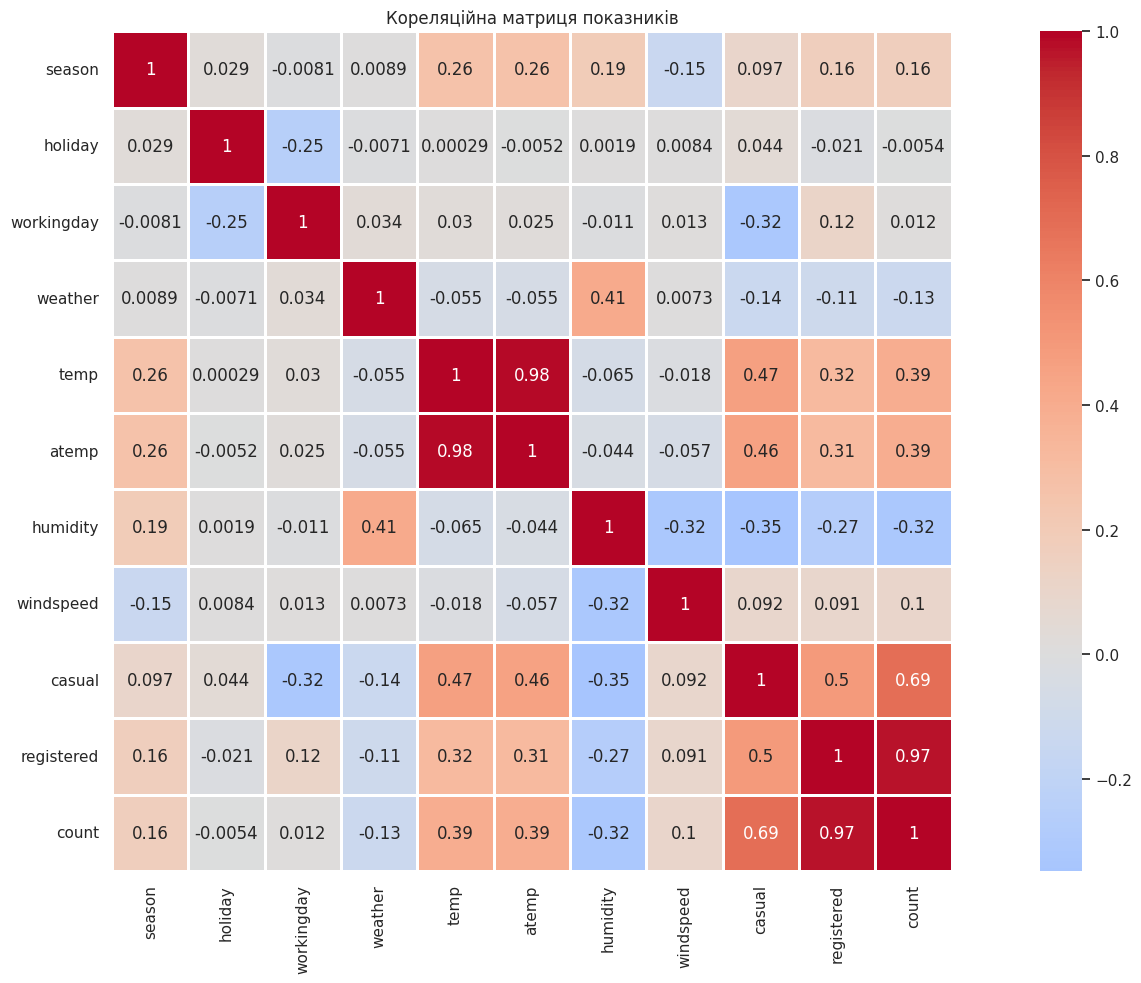

In [ ]:
plt.figure(figsize=(18, 10))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. registered - 0.97 майже абсолютний позитивний зв'язок, casual - сильний позитивний зв'язок, temp - 0.39 - зі зростанням температури зростає попит.

2.Кореляція становить 0.98. temp — це фактична виміряна температура повітря, а atemp — це «відчувається як». Показник atemp безпосередньо розраховується на основі фактичної температури з невеликими поправками на вологість та швидкість вітру.

3. На графіку це клітинки, забарвлені у блакитні відтінки.

1.humidity (вологість) має негативну кореляцію з:

орендою велосипедів: count (-0.32), casual (-0.35), registered (-0.27);

швидкістю вітру: windspeed (-0.32);

температурою: temp (-0.065), atemp (-0.044).

2.weather (погіршення погоди: дощ/туман) негативно корелює з:

кількістю оренд: count (-0.13), casual (-0.14), registered (-0.11);

температурою: temp (-0.055), atemp (-0.055).

3.workingday (робочий день): має негативну кореляцію з casual (-0.32) та holiday (-0.25), оскільки у будні дні туристи та разові користувачі катаються значно менше, ніж у вихідні.

4.season та windspeed (-0.15): швидкість вітру в окремі сезони має тенденцію до зниження.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


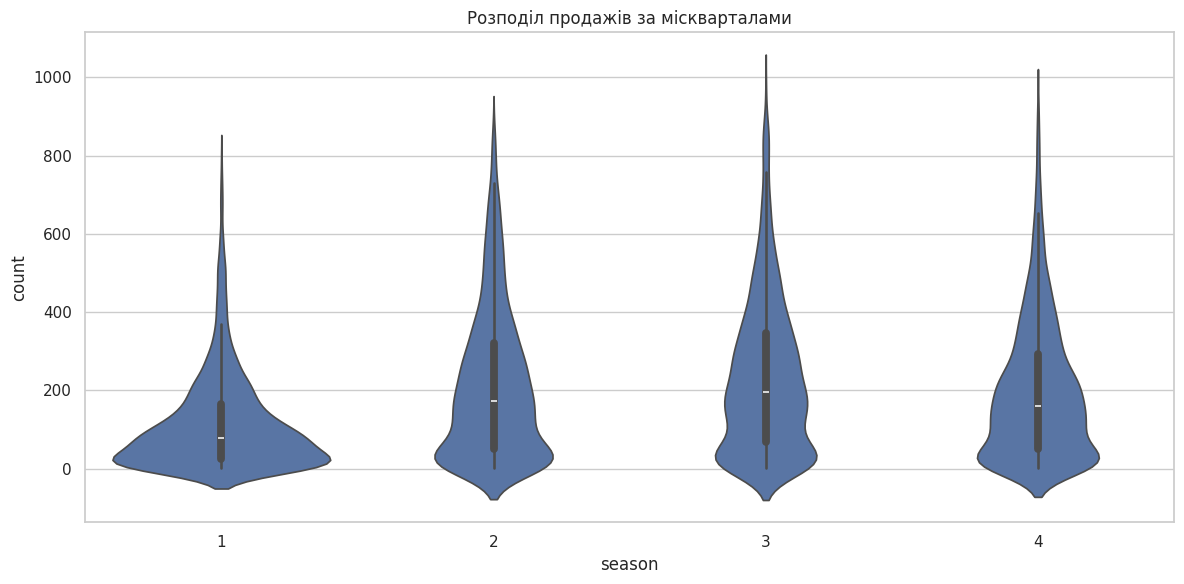

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count',
               )
plt.xticks(rotation=0)
plt.title('Розподіл продажів за міскварталами')
plt.tight_layout()
plt.show()

1. Ширина фігури в будь-якій точці показує, наскільки часто зустрічається конкретна кількість оренд. Це по суті симетрично розгорнута крива KDE.
2. Фігура 3-го кварталу має найбільшу вертикальну протяжність. Це вказує на максимальний розкид значень: від нульових оренд уночі до рекордних піків удень.
3. Вox plot показує лише 5 базових числових точок (мінімум, 1-й квартиль, медіану, 3-й квартиль, максимум) і приховує характер розподілу всередині коробки. Violin plot повністю розкриває геометрію даних.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

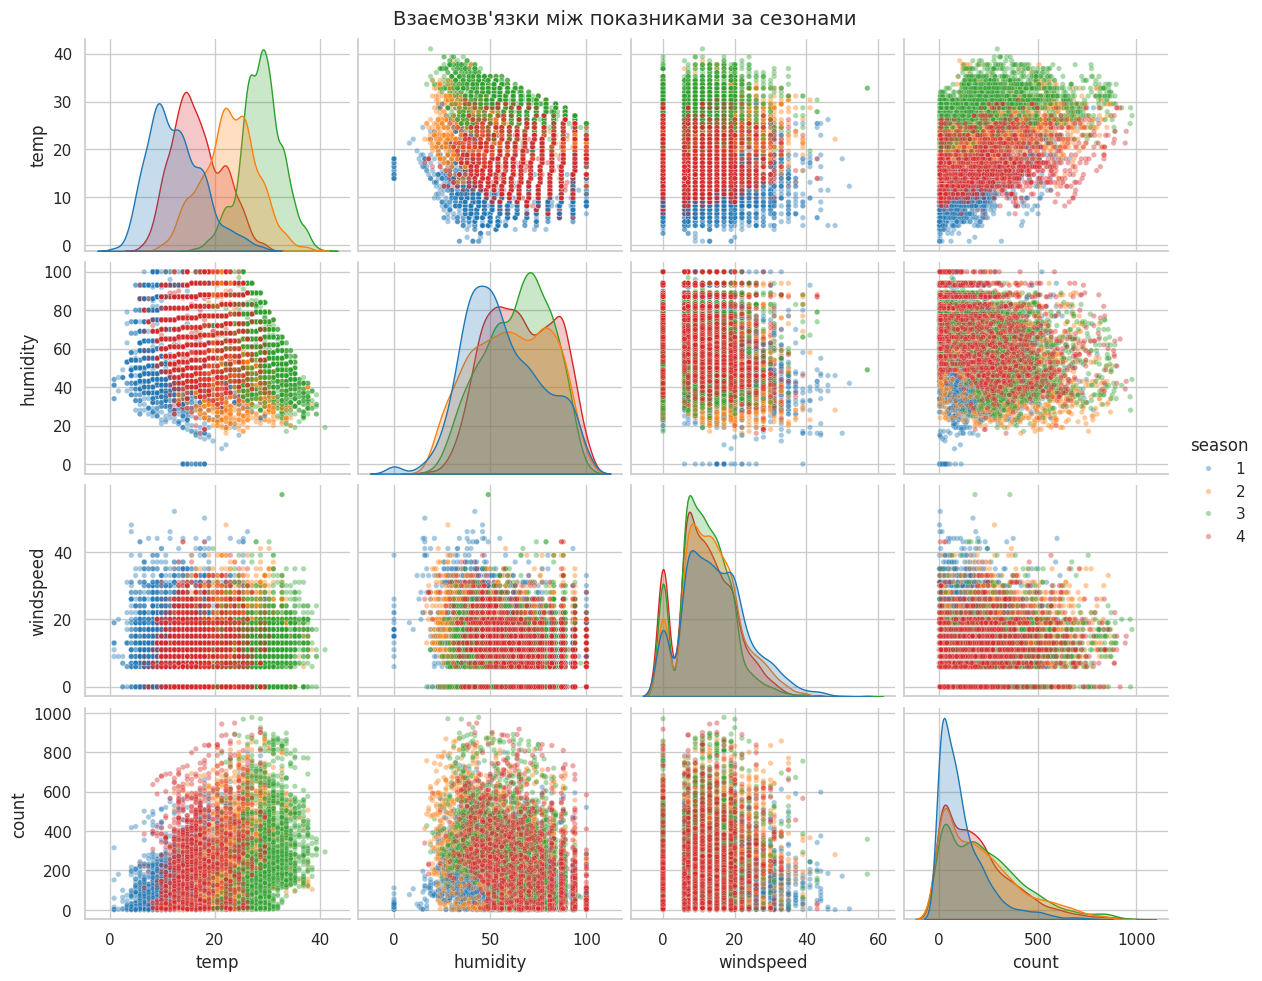

In [ ]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

g = sns.pairplot(
    sample_df,
    hue='season',
    palette='tab10',
    height=2.5,
    aspect=1.2,
    plot_kws={'alpha': 0.4, 's': 15}
)
g.figure.subplots_adjust(top=0.95)
g.figure.suptitle("Взаємозв'язки між показниками за сезонами", fontsize=14)

plt.show()

1. Між temp (температурою) та count (кількістю оренди).
Серед пар представлених змінних саме тут найпомітніший висхідний лінійний тренд.

2. Найбільше відрізняється temp і windspeed.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

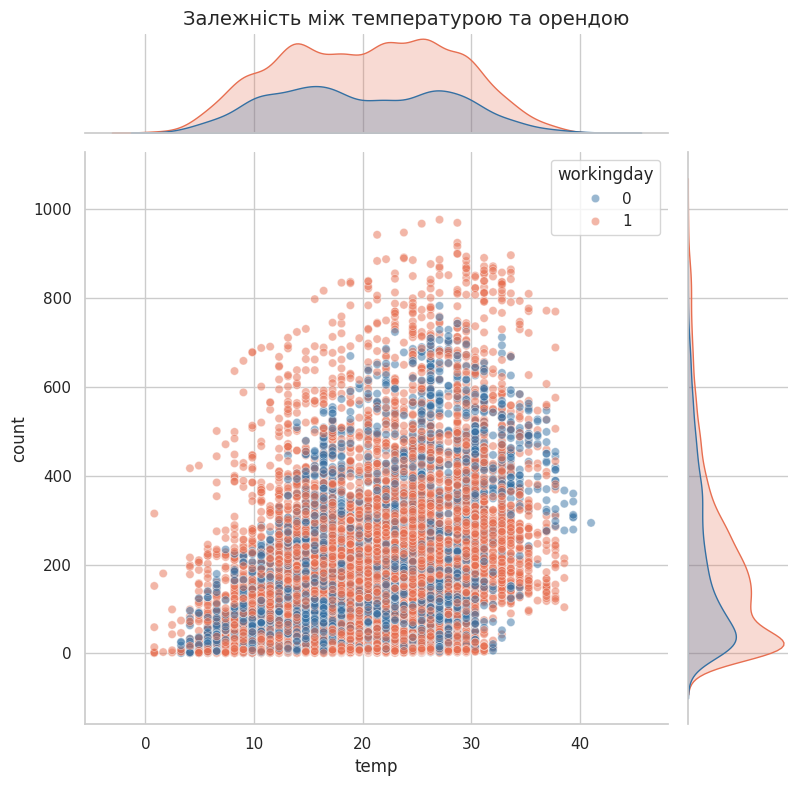

In [ ]:
sample_df = df[['temp', 'count', 'workingday']]

g = sns.jointplot(
    data=sample_df,
    x='temp',
    y='count',
    hue='workingday',
    palette=['#3470a3', '#e76f51'],
    height=8,
    joint_kws={'alpha': 0.5}
)

g.figure.subplots_adjust(top=0.95)
g.figure.suptitle("Залежність між температурою та орендою", fontsize=14)

plt.show()

1. Верхній графік: показує одновимірний розподіл незалежної змінної на осі X — температури (temp) окремо для робочих (1) та неробочих (0) днів.

Правий графік: показує одновимірний розподіл цільової змінної на осі Y — кількості оренд (count) для обох категорій днів.

2. Залежність від температури однакова: в обох типах днів зі зростанням температури зростає й кількість оренд.

Різниця в пікових навантаженнях:

У робочі дні (workingday = 1) спостерігається більша кількість екстремально високих значень (точки від 600 до 900+ оренд). Це зумовлено ранковими та вечірніми годинами пік (маятникова міграція на роботу/навчання).

У неробочі дні (workingday = 0) попит рідко сягає екстремальних максимумів вище 700–800, але має більш рівномірний розподіл у денні години без різких піків поїздки на роботу.